In [ ]:
# Importar
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [ ]:
# Ver datasets
sns.get_dataset_names()

# Dataset Titanic
df_titanic = sns.load_dataset("titanic")

# Mostrar 1as filas
df_titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# Muestra del dataset
print(df_titanic.head())

# Informacion básica
print("\nINFO DATASET:")
print(df_titanic.info())

# Nulos por columna
print("\nNULOS POR COLUMNA:")
print(df_titanic.isnull().sum())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

INFO DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived

In [ ]:
# Porcentaje de nulos
porcentaje_nulos = (df_titanic.isnull().mean() * 100).round(2)
print("Porcentaje de nulos:\n", porcentaje_nulos)

# - Eliminaremos 'deck' (muchos nulos)
# - Rellenaremos 'age' con mediana
# - Rellenaremos 'embarked' con moda
# - Eliminar columna 'parch' es decir NO la vamos a usar

df_titanic = df_titanic.drop(columns=["deck", "parch"])

df_titanic["age"].fillna(df_titanic["age"].median(), inplace=True)
df_titanic["embarked"].fillna(df_titanic["embarked"].mode()[0], inplace=True)

# Vemos si hemos conseguido lo que hemos dicho anteriormente
print(df_titanic.isnull().sum())

Porcentaje de nulos:
 survived        0.00
pclass          0.00
sex             0.00
age            19.87
sibsp           0.00
parch           0.00
fare            0.00
embarked        0.22
class           0.00
who             0.00
adult_male      0.00
deck           77.22
embark_town     0.22
alive           0.00
alone           0.00
dtype: float64
survived       0
pclass         0
sex            0
age            0
sibsp          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


C:\Users\34667\AppData\Local\Temp\ipykernel_4736\320491515.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_titanic["age"].fillna(df_titanic["age"].median(), inplace=True)
C:\Users\34667\AppData\Local\Temp\ipykernel_4736\320491515.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

In [8]:
descripcion_columnas = {
    "survived": "Indica si el pasajero sobrevivió (1) o no (0)",
    "pclass": "Clase del billete (1 = primera, 2 = segunda, 3 = tercera)",
    "sex": "Sexo del pasajero",
    "age": "Edad del pasajero",
    "sibsp": "Número de familiares que viajaban con el pasajero",
    "fare": "Precio del billete",
    "embarked": "Inicial del puerto de embarque",
    "class": "Clase del pasajero en texto",
    "who": "Categoría: hombre, mujer o niño",
    "adult_male": "Indica si es un hombre adulto",
    "embark_town": "Ciudad donde embarcó",
    "alive": "Indica si sobrevivió (yes/no)",
    "alone": "Indica si viajaba solo"
}

for col, desc in descripcion_columnas.items():
    print(f"{col}: {desc}")

survived: Indica si el pasajero sobrevivió (1) o no (0)
pclass: Clase del billete (1 = primera, 2 = segunda, 3 = tercera)
sex: Sexo del pasajero
age: Edad del pasajero
sibsp: Número de familiares que viajaban con el pasajero
fare: Precio del billete
embarked: Inicial del puerto de embarque
class: Clase del pasajero en texto
who: Categoría: hombre, mujer o niño
adult_male: Indica si es un hombre adulto
embark_town: Ciudad donde embarcó
alive: Indica si sobrevivió (yes/no)
alone: Indica si viajaba solo


In [ ]:
# Reemplazamos iniciales con nomrbes completos
mapa_ciudades = {
    "S": "Southampton",
    "C": "Cherbourg",
    "Q": "Queenstown"
}

df_titanic["embarked"] = df_titanic["embarked"].map(mapa_ciudades)

df_titanic["embarked"].value_counts()

embarked
Southampton    646
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [10]:
variables = ["survived","who","age","fare","class","embarked","alone"]

survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


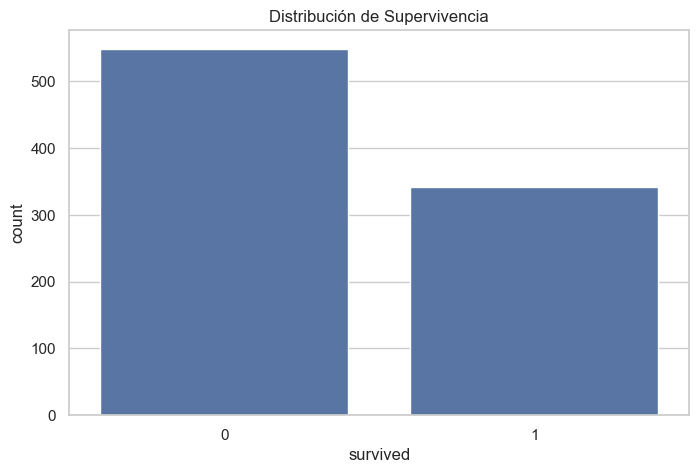

In [ ]:
print(df_titanic["survived"].value_counts(normalize=True)*100)

sns.countplot(data=df_titanic, x="survived")
plt.title("Distribución de Supervivencia")
plt.show()

# Conclusiones:
# - La mayoría de pasajeros NO sobrevivieron
# - Aproximadamente el 38% sobrevivió

who
man      60.269360
woman    30.415264
child     9.315376
Name: proportion, dtype: float64


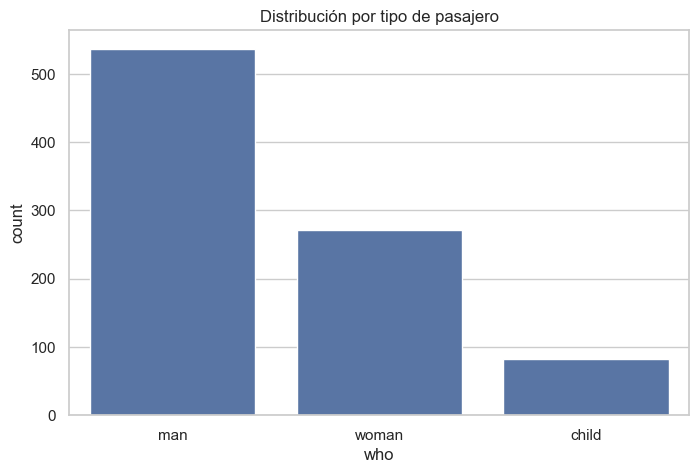

In [ ]:
print(df_titanic["who"].value_counts(normalize=True)*100)

sns.countplot(data=df_titanic, x="who")
plt.title("Distribución por tipo de pasajero")
plt.show()

# Conclusiones:
# - Predominan hombres adultos
# - Menor de niños

class
Third     55.106622
First     24.242424
Second    20.650954
Name: proportion, dtype: float64


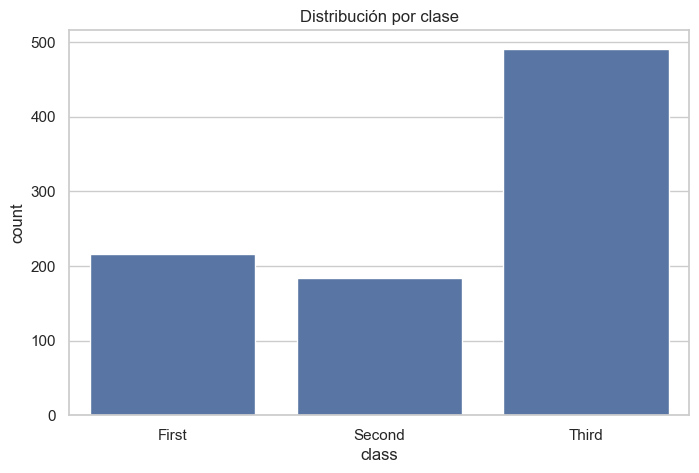

In [13]:
print(df_titanic["class"].value_counts(normalize=True)*100)

sns.countplot(data=df_titanic, x="class")
plt.title("Distribución por clase")
plt.show()

# Conclusiones:
# - La mayoría viajaba en tercera clase
# - Primera clase es minoritaria

embarked
Southampton    72.502806
Cherbourg      18.855219
Queenstown      8.641975
Name: proportion, dtype: float64


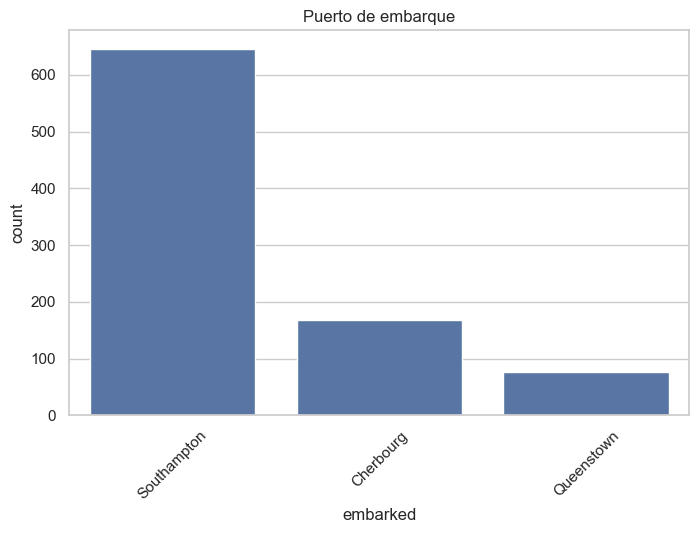

In [ ]:
print(df_titanic["embarked"].value_counts(normalize=True)*100)

sns.countplot(data=df_titanic, x="embarked")
plt.title("Puerto de embarque")
plt.xticks(rotation=45)
plt.show()

# Conclusiones:
# - Southampto puerto de embarque mayor
# - Cherbourg y Queenstown tuvieron menos pasajeros

alone
True     60.26936
False    39.73064
Name: proportion, dtype: float64


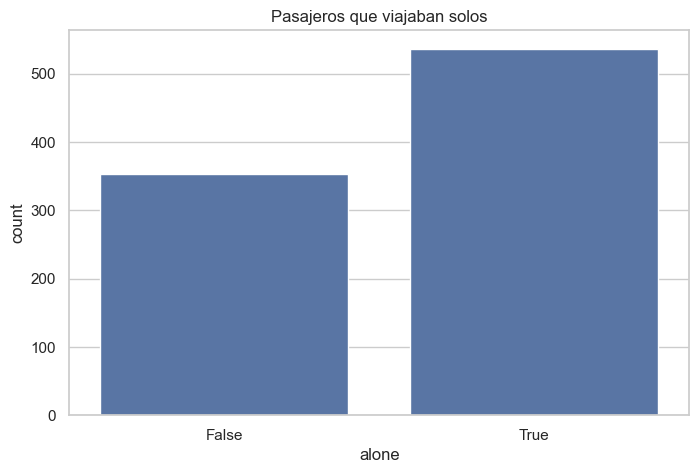

In [ ]:
print(df_titanic["alone"].value_counts(normalize=True)*100)

sns.countplot(data=df_titanic, x="alone")
plt.title("Pasajeros que viajaban solos")
plt.show()

# Conclusiones:
# - Muchos pasajeros viajaban solos


count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: age, dtype: float64


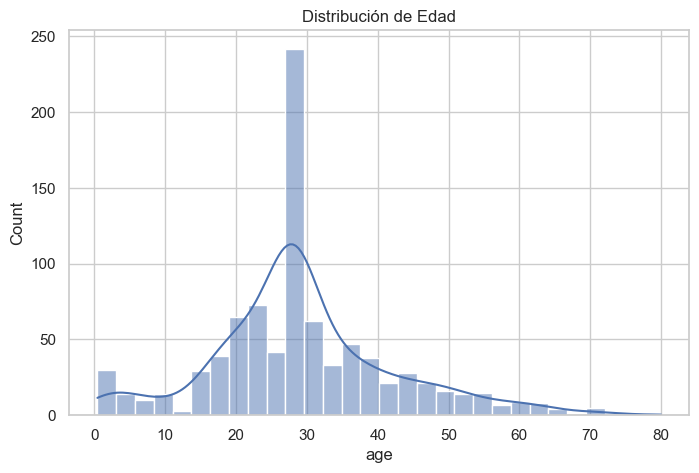

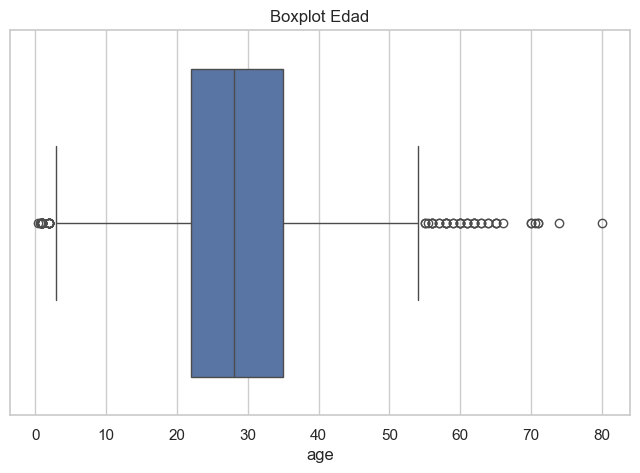

In [ ]:
print(df_titanic["age"].describe())

sns.histplot(df_titanic["age"], kde=True)
plt.title("Distribución de Edad")
plt.show()

sns.boxplot(x=df_titanic["age"])
plt.title("Boxplot Edad")
plt.show()

# Conclusiones:
# - La mayoría de pasajeros eran adultos jóvenes